<a href="https://colab.research.google.com/github/nikitask14/neural-networks-pytorch-from-first-principles/blob/main/04_debugging_and_generalisation/13_learningcurves_and_overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import torch
import torch.nn as nn

In [16]:
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(2,16)
    self.layer2 = nn.Linear(16, 16)
    self.layer3 = nn.Linear(16,1)

  def forward(self, x):
    x = self.layer1(x)
    x = torch.relu(x)

    x = self.layer2(x)
    x = torch.relu(x)

    x = self.layer3(x)

    return x

x_train = torch.tensor([
    [ 2.0,  2.0],
    [ 1.5,  1.0],
    [-2.0, -2.0],
    [-1.5, -1.0],
    [ 2.0, -2.0],
    [ 1.5, -1.0],
    [-2.0,  2.0],
    [-1.5,  1.0]
], dtype = torch.float32)

y_train = torch.tensor([
    [1.0],
    [0.0],   # deliberately noisy label
    [1.0],
    [1.0],
    [0.0],
    [1.0],   # deliberately noisy label
    [0.0],
    [0.0]
], dtype = torch.float32)

x_val = torch.tensor([
    [ 1.8,  1.5],
    [ 1.2,  0.8],
    [-1.8, -1.5],
    [-1.2, -0.8],
    [ 1.8, -1.5],
    [ 1.2, -0.8],
    [-1.8,  1.5],
    [-1.2,  0.8]
])

y_val = torch.tensor([
     [1.0],
    [1.0],
    [1.0],
    [1.0],
    [0.0],
    [0.0],
    [0.0],
    [0.0]
], dtype = torch.float32)

print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

model = MyModel()
optimiser = torch.optim.SGD(model.parameters(), lr = 0.01)
loss_fn = nn.BCEWithLogitsLoss()

# Right now, every epoch calculates a new training loss and validation
#loss  but the variables get overwritten.
# After 500 epochs, Python only remembers the latest values.

# Create two empty lists to keep every epoch training
# and validation loss
train_losses = []
val_losses = []

for epoch in range(2500):
  model.train()
  optimiser.zero_grad()
  train_logits = model(x_train)
  train_loss = loss_fn(train_logits, y_train)
  train_loss.backward()
  optimiser.step()

  model.eval()
  with torch.no_grad():
    train_logits_eval = model(x_train)
    train_loss_eval = loss_fn(
            train_logits_eval,
            y_train
        )
    val_logits = model(x_val)
    val_loss = loss_fn(val_logits, y_val)

    train_losses.append(train_loss_eval.item())
    val_losses.append(val_loss.item())

  if epoch %50 == 0:

    print(f"Epoch: {epoch}, Training Loss:{train_loss},"
    f"Validation Loss:{val_loss}")
print(len(train_losses))
print(len(val_losses))



torch.Size([8, 2])
torch.Size([8, 1])
torch.Size([8, 2])
torch.Size([8, 1])
Epoch: 0, Training Loss:0.6810629367828369,Validation Loss:0.6990983486175537
Epoch: 50, Training Loss:0.6589252948760986,Validation Loss:0.6849924325942993
Epoch: 100, Training Loss:0.6402072906494141,Validation Loss:0.6737560033798218
Epoch: 150, Training Loss:0.6213657855987549,Validation Loss:0.6625452637672424
Epoch: 200, Training Loss:0.6028020977973938,Validation Loss:0.6510598063468933
Epoch: 250, Training Loss:0.5836234092712402,Validation Loss:0.6394070982933044
Epoch: 300, Training Loss:0.5645713806152344,Validation Loss:0.6266812086105347
Epoch: 350, Training Loss:0.5447792410850525,Validation Loss:0.6129594445228577
Epoch: 400, Training Loss:0.524897575378418,Validation Loss:0.5982401371002197
Epoch: 450, Training Loss:0.505378007888794,Validation Loss:0.5827459692955017
Epoch: 500, Training Loss:0.486709326505661,Validation Loss:0.5669850707054138
Epoch: 550, Training Loss:0.4694159924983978,Valid

<function matplotlib.pyplot.show(close=None, block=None)>

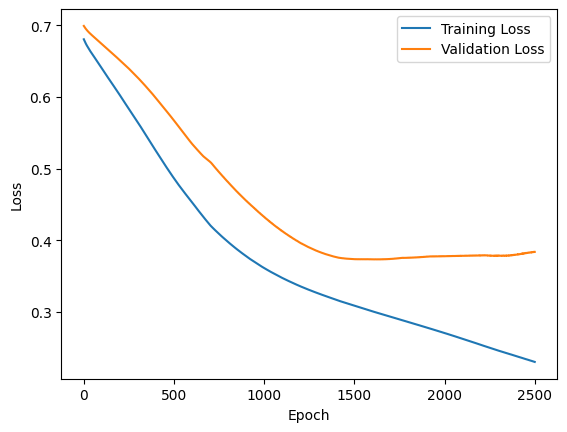

In [17]:
# matplotlib is a Python plotting library.
# pyplot contains the plotting functions
# plt simply gives it the short name plt.

import matplotlib.pyplot as plt

# take the values stored in train_losses and draw them as a line.
# train_losses = the actual values to plot
# label="Training Loss" = simply gives that plotted line a name
plt.plot(train_losses, label ="Training Loss")

# take the values stored in val_losses and draw them as a line.
plt.plot(val_losses, label = "Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show


**Meaning:**

xlabel() → name the horizontal axis


ylabel() → name the vertical axis


legend() → show which line is training vs validation


show() → display the graph

The three patterns we want to recognise are:

1. **Healthy generalisation:** training loss decreases, validation loss also decreases and stays reasonably close.
2. **Underfitting:** both training and validation losses remain relatively high; the model has not learned the pattern well enough even on the training data.
3. **Overfitting:** training loss keeps decreasing, but validation loss stops improving and eventually rises.